# Day 4: Data Exploration

In this notebook, we will load the AG News dataset and perform some initial exploration to understand its structure and content.

In [1]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("Train dataset loaded.")
train_df.head()

Train dataset loaded.


,text,label
0,AMD #39;s new dual-core Opteron chip is design...,3
1,Reuters - Major League Baseball\Monday announc...,1
2,President Bush #39;s quot;revenue-neutral quo...,2
3,Britain will run out of leading scientists unl...,3
4,"London, England (Sports Network) - England mid...",1


In [2]:
print("Test dataset loaded.")
test_df.head()

Test dataset loaded.


,text,label
0,"CHARLOTTE, N.C. (Sports Network) - Carolina P...",1
1,"PRESENTACION, Philippines (Reuters) - Philipp...",0
2,"SAN FRANCISCO, CA - November 30, 2004 -Ubisoft...",3
3,DANIEL VETTORI spun New Zealand to the brink o...,1
4,AFP - Georgian and South Ossetian forces overn...,0


In [3]:
# Get information about the training data
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    120000 non-null  object
 1   label   120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


In [4]:
# Check for missing values
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
text     0
label    0
dtype: int64

Missing values in test data:
text     0
label    0
dtype: int64


In [5]:
# Look at the class distribution
print("Class distribution in training data:")
print(train_df['label'].value_counts())

Class distribution in training data:
label
3    30000
1    30000
2    30000
0    30000
Name: count, dtype: int64


# Data Exploration and Preprocessing

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training data
df = pd.read_csv('../data/train.csv')

# Display the first few rows
print(df.head())

# Display info
print(df.info())

                                                text  label
0  AMD #39;s new dual-core Opteron chip is design...      3
1  Reuters - Major League Baseball\Monday announc...      1
2  President Bush #39;s  quot;revenue-neutral quo...      2
3  Britain will run out of leading scientists unl...      3
4  London, England (Sports Network) - England mid...      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    120000 non-null  object
 1   label   120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB
None


In [7]:
# Check for missing values
print(df.isnull().sum())

text     0
label    0
dtype: int64


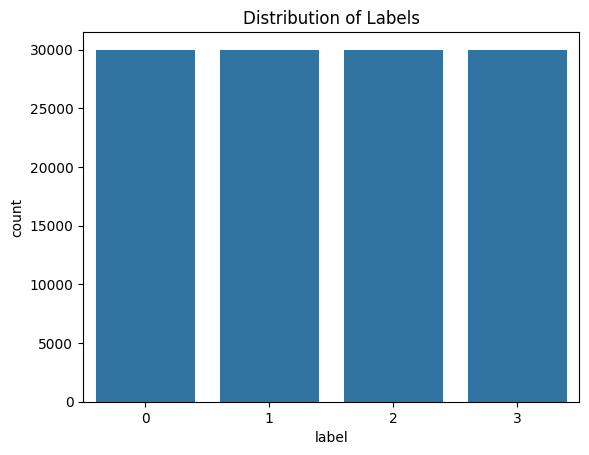

In [8]:
# Show distribution of labels
sns.countplot(x='label', data=df)
plt.title('Distribution of Labels')
plt.show()

## Text Preprocessing

In [9]:
import re
import string

def clean_text(text):
    """
    Cleans text by removing punctuation, and converting to lowercase.
    """
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

# Apply the cleaning function
df['cleaned_text'] = df['text'].apply(clean_text)
print(df[['text', 'cleaned_text']].head())

                                                text  \
0  AMD #39;s new dual-core Opteron chip is design...   
1  Reuters - Major League Baseball\Monday announc...   
2  President Bush #39;s  quot;revenue-neutral quo...   
3  Britain will run out of leading scientists unl...   
4  London, England (Sports Network) - England mid...   

                                        cleaned_text  
0  amd 39s new dualcore opteron chip is designed ...  
1  reuters  major league baseballmonday announced...  
2  president bush 39s  quotrevenueneutral quot ta...  
3  britain will run out of leading scientists unl...  
4  london england sports network  england midfiel...  


In [14]:
import nltk
from nltk.tokenize import word_tokenize

# Download nltk resources
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Tokenize the text
df['tokenized_text'] = df['cleaned_text'].apply(word_tokenize)
print(df[['cleaned_text', 'tokenized_text']].head())

                                        cleaned_text  \
0  amd 39s new dualcore opteron chip is designed ...   
1  reuters  major league baseballmonday announced...   
2  president bush 39s  quotrevenueneutral quot ta...   
3  britain will run out of leading scientists unl...   
4  london england sports network  england midfiel...   

                                      tokenized_text  
0  [amd, 39s, new, dualcore, opteron, chip, is, d...  
1  [reuters, major, league, baseballmonday, annou...  
2  [president, bush, 39s, quotrevenueneutral, quo...  
3  [britain, will, run, out, of, leading, scienti...  
4  [london, england, sports, network, england, mi...  


In [13]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/apple/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/apple/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True